In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def mostrar_imagen(img, titulo="Imagen"):
    plt.figure(figsize=(10,6))
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(titulo)
    plt.axis('off')
    plt.show()

img1 = cv2.imread('1.png')
img2 = cv2.imread('2.png')
img3 = cv2.imread('3.png')

# repo en la branch del lab4 https://github.com/donmatthiuz/VIC/tree/lab4

In [2]:
def detectar_y_emparejar(img1, img2):
    sift = cv2.SIFT_create()

    kp1, des1 = sift.detectAndCompute(img1, None)
    kp2, des2 = sift.detectAndCompute(img2, None)

    bf = cv2.BFMatcher()
    matches = bf.knnMatch(des1, des2, k=2)

    good_matches = []
    for m, n in matches:
        if m.distance < 0.75 * n.distance:
            good_matches.append(m)

    src_pts = np.float32([kp1[m.queryIdx].pt for m in good_matches])
    dst_pts = np.float32([kp2[m.trainIdx].pt for m in good_matches])

    return src_pts, dst_pts, good_matches, kp1, kp2

src_pts, dst_pts, matches, kp1, kp2 = detectar_y_emparejar(img1, img2)

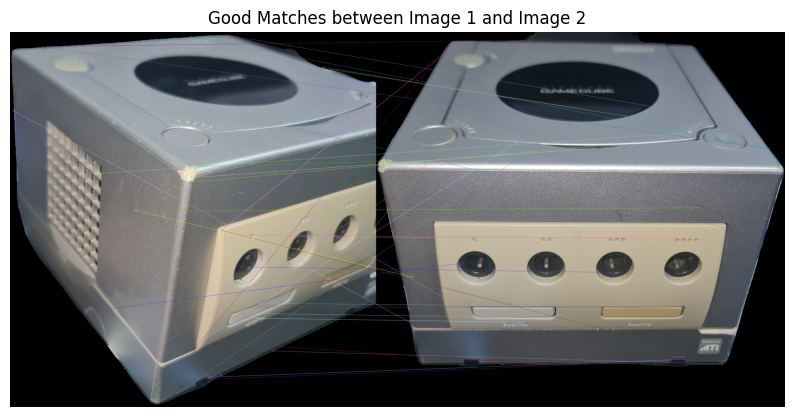

In [3]:
img_matches = cv2.drawMatches(img1, kp1, img2, kp2, matches, None, flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
mostrar_imagen(img_matches, 'Good Matches between Image 1 and Image 2')

## Resultados
Logró encontrar similitudes, en algunas partes como las memorias, los botones y los puertos de los controles, la imagen subida no esta completa (imagen 1) así que colocar una imagen completa de la gamecube podría ayudar a mejorar los resultados
